# Food Delivery Time Analysis: Weather, Traffic, and Customer Satisfaction

## Introduction

Food delivery performance is affected by several factors such as weather conditions, traffic levels, delivery distance, and preparation time. These factors can influence the total time a customer waits and may also impact customer satisfaction.

This project analyzes a food delivery dataset to understand the main factors that affect delivery time and customer satisfaction. The analysis focuses on cleaning the data, creating useful features, exploring delivery patterns, and identifying insights that can support better operational decisions.

The project is divided into three main parts: Python analysis for data cleaning and exploratory analysis, SQL analysis for answering business questions, and Power BI for building interactive visualizations and dashboards.


## Project Overview

This project is organized into three main sections, each focusing on a different stage of the data analysis workflow:

* **Python Analysis:**
  Data cleaning, handling missing values, feature engineering, exploratory data analysis (EDA), and statistical analysis to understand delivery performance and customer satisfaction patterns.

* **SQL Analysis:**
  Writing SQL queries to answer business-related questions, perform aggregations, analyze operational performance, and extract meaningful insights from the dataset.

* **Power BI Dashboard:**
  Building interactive dashboards and visualizations to present key metrics, delivery trends, customer satisfaction insights, and operational performance in a clear and user-friendly format.


## Dataset Description

The dataset contains information related to food delivery operations, including delivery times, weather conditions, traffic levels, delivery distances, preparation times, and customer satisfaction ratings.

Each row represents a delivery order and includes operational and environmental factors that may influence delivery performance. The dataset is used to analyze patterns, identify inefficiencies, and understand the relationship between delivery conditions and customer experience.


<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3
from sklearn.preprocessing import LabelEncoder 
from sklearn.ensemble import RandomForestClassifier

In [2]:
df= pd.read_csv('Food_Delivery_Times.csv')

<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

## Data Cleaning

In this section, the dataset was inspected and cleaned by checking its structure, reviewing column names and data types, handling missing values, removing duplicates, reshaping the data, and standardizing the dataset for further analysis.


In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
df.shape

(1000, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [7]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [8]:
df.describe().round(2)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.00,1000.00,1000.00,970.00,1000.00
mean,500.50,10.06,16.98,4.58,56.73
std,288.82,5.70,7.20,2.91,22.07
min,1.00,0.59,5.00,0.00,8.00
25%,250.75,5.11,11.00,2.00,41.00
50%,500.50,10.19,17.00,5.00,55.50
75%,750.25,15.02,23.00,7.00,71.00
max,1000.00,19.99,29.00,9.00,153.00


In [9]:
df = df.sort_values('Order_ID').reset_index(drop=True)

In [10]:
df.nunique()

Order_ID                  1000
Distance_km                785
Weather                      5
Traffic_Level                3
Time_of_Day                  4
Vehicle_Type                 3
Preparation_Time_min        25
Courier_Experience_yrs      10
Delivery_Time_min          108
dtype: int64

In [11]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### Predicting Missing Traffic Levels

Missing values in the `Traffic_Level` column were handled using a Random Forest Classification model. The model was trained using related features such as weather conditions, time of day, delivery time, and delivery distance to predict the most likely traffic category for missing records.

Categorical variables were encoded before training the model to allow the algorithm to process the data correctly. This approach helps preserve realistic relationships within the dataset instead of using simple filling methods.


In [13]:
traffic_missing_index = df[df['Traffic_Level'].isna()].index

model_data = df[
    df['Weather'].notna() &
    df['Time_of_Day'].notna() &
    df['Traffic_Level'].notna()
].copy()

missing_data = df[
    df['Traffic_Level'].isna() &
    df['Weather'].notna() &
    df['Time_of_Day'].notna()
].copy()

weather_encoder = LabelEncoder()
time_encoder = LabelEncoder()

model_data['Weather_Encoded'] = weather_encoder.fit_transform(model_data['Weather'])
model_data['Time_Encoded'] = time_encoder.fit_transform(model_data['Time_of_Day'])

missing_data['Weather_Encoded'] = weather_encoder.transform(missing_data['Weather'])
missing_data['Time_Encoded'] = time_encoder.transform(missing_data['Time_of_Day'])

x_train = model_data[['Weather_Encoded', 'Time_Encoded', 'Delivery_Time_min', 'Distance_km']]
y_train = model_data['Traffic_Level']

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

x_missing = missing_data[['Weather_Encoded', 'Time_Encoded', 'Delivery_Time_min', 'Distance_km']]
predicted_values = model.predict(x_missing)

df.loc[missing_data.index, 'Traffic_Level'] = predicted_values

In [14]:
df.loc[traffic_missing_index, ['Weather', 'Time_of_Day', 'Delivery_Time_min', 'Distance_km', 'Traffic_Level']]

,Weather,Time_of_Day,Delivery_Time_min,Distance_km,Traffic_Level
18,Windy,Morning,62,8.92,Medium
40,Rainy,Morning,41,2.88,Medium
75,Clear,Evening,80,14.72,Medium
78,Clear,Morning,45,7.49,High
91,Rainy,Night,85,14.41,High
97,Clear,Morning,57,8.84,High
129,Clear,Evening,68,10.46,Medium
138,Clear,Afternoon,37,7.59,Low
163,Snowy,Afternoon,65,10.95,Medium
203,Clear,Evening,77,18.02,Low


### Predicting Missing Weather Conditions

Missing values in the `Weather` column were predicted using a Random Forest Classification model. The model used related features such as traffic level, time of day, delivery time, and delivery distance to estimate the most likely weather condition for missing records.

Categorical features were encoded before training the model to ensure compatibility with the machine learning algorithm. This method helps maintain realistic relationships between operational and environmental factors in the dataset.


In [15]:
weather_missing_index = df[df['Weather'].isna()].index

model_data = df[
    df['Traffic_Level'].notna() &
    df['Time_of_Day'].notna() &
    df['Weather'].notna()
].copy()

missing_data = df[
    df['Weather'].isna() &
    df['Traffic_Level'].notna() &
    df['Time_of_Day'].notna()
].copy()

traffic_encoder = LabelEncoder()
time_encoder = LabelEncoder()

model_data['Traffic_Encoded'] = traffic_encoder.fit_transform(model_data['Traffic_Level'])
model_data['Time_Encoded'] = time_encoder.fit_transform(model_data['Time_of_Day'])

missing_data['Traffic_Encoded'] = traffic_encoder.transform(missing_data['Traffic_Level'])
missing_data['Time_Encoded'] = time_encoder.transform(missing_data['Time_of_Day'])

x_train = model_data[['Traffic_Encoded', 'Time_Encoded', 'Delivery_Time_min', 'Distance_km']]
y_train = model_data['Weather']

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

x_missing = missing_data[['Traffic_Encoded', 'Time_Encoded', 'Delivery_Time_min', 'Distance_km']]

predicted_values = model.predict(x_missing)

df.loc[missing_data.index, 'Weather'] = predicted_values

In [16]:
df.loc[weather_missing_index,['Traffic_Level','Time_of_Day','Delivery_Time_min','Distance_km','Weather']]

,Traffic_Level,Time_of_Day,Delivery_Time_min,Distance_km,Weather
2,High,Morning,67,14.77,Clear
57,Medium,Morning,36,4.32,Clear
69,Low,NaN,71,19.74,NaN
123,Medium,Afternoon,35,2.65,Clear
125,Medium,Evening,109,8.83,Clear
126,Medium,Evening,87,16.45,Clear
150,Low,Evening,74,18.21,Clear
152,Medium,Evening,44,3.33,Rainy
222,Low,Morning,17,2.33,Clear
293,Medium,Afternoon,44,7.52,Clear


### Predicting Missing Time of Day Values

Missing values in the `Time_of_Day` column were predicted using a Random Forest Classification model based on related operational features such as traffic level, weather conditions, delivery time, and delivery distance.

Before training the model, categorical variables were encoded to make them suitable for machine learning processing. Using predictive modeling for missing values helps preserve patterns and relationships within the dataset more effectively than simple replacement methods.


In [17]:
time_missing_index = df[df['Time_of_Day'].isna()].index

model_data = df[
    df['Traffic_Level'].notna() &
    df['Weather'].notna() &
    df['Time_of_Day'].notna()
].copy()

missing_data = df[
    df['Time_of_Day'].isna() &
    df['Traffic_Level'].notna() &
    df['Weather'].notna()
].copy()

traffic_encoder = LabelEncoder()
weather_encoder = LabelEncoder()

model_data['Traffic_Encoded'] = traffic_encoder.fit_transform(model_data['Traffic_Level'])
model_data['Weather_Encoded'] = weather_encoder.fit_transform(model_data['Weather'])

missing_data['Traffic_Encoded'] = traffic_encoder.transform(missing_data['Traffic_Level'])
missing_data['Weather_Encoded'] = weather_encoder.transform(missing_data['Weather'])

x_train = model_data[['Traffic_Encoded', 'Weather_Encoded', 'Delivery_Time_min', 'Distance_km']]
y_train = model_data['Time_of_Day']

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

x_missing = missing_data[['Traffic_Encoded', 'Weather_Encoded', 'Delivery_Time_min', 'Distance_km']]

predicted_values = model.predict(x_missing)

df.loc[missing_data.index, 'Time_of_Day'] = predicted_values

In [18]:
df.loc[time_missing_index,['Traffic_Level','Weather','Delivery_Time_min','Distance_km','Time_of_Day']]

,Traffic_Level,Weather,Delivery_Time_min,Distance_km,Time_of_Day
4,Low,Foggy,37,3.54,Morning
25,Low,Clear,92,15.81,Morning
69,Low,NaN,71,19.74,NaN
84,Medium,Windy,47,6.56,Afternoon
149,High,Foggy,106,5.93,Afternoon
156,Low,Clear,43,13.61,Morning
189,Medium,Snowy,43,5.22,Morning
196,Medium,Windy,77,14.66,Morning
228,Low,Windy,101,17.89,Morning
238,Low,Windy,69,13.09,Morning


### Final Missing Value Handling

After applying predictive modeling to fill most missing categorical values, a few records still contained missing values. Since the remaining missing data was very small, those rows were removed. The `Courier_Experience_yrs` column was filled using the median value to avoid the effect of extreme values.


In [19]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [20]:
df['Courier_Experience_yrs'].median()

np.float64(5.0)

In [21]:
df = df.dropna()

In [22]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [23]:
print(df['Weather'].value_counts())
print(df['Traffic_Level'].value_counts())
print(df['Time_of_Day'].value_counts())
print(df['Vehicle_Type'].value_counts())
print(df['Preparation_Time_min'].value_counts())
print(df['Courier_Experience_yrs'].value_counts())

Weather
Clear    489
Rainy    208
Foggy    106
Windy     98
Snowy     97
Name: count, dtype: int64
Traffic_Level
Medium    404
Low       391
High      203
Name: count, dtype: int64
Time_of_Day
Morning      323
Evening      298
Afternoon    291
Night         86
Name: count, dtype: int64
Vehicle_Type
Bike       503
Scooter    301
Car        194
Name: count, dtype: int64
Preparation_Time_min
14    52
16    49
25    48
10    47
11    46
9     46
17    45
6     44
8     42
22    42
27    40
28    40
26    40
20    39
23    38
12    38
21    38
29    38
24    37
7     37
19    35
13    30
5     30
15    29
18    28
Name: count, dtype: int64
Courier_Experience_yrs
5.0    120
6.0    109
9.0    108
1.0    106
8.0    101
2.0     99
4.0     94
0.0     91
7.0     90
3.0     80
Name: count, dtype: int64


The frequency of categorical values was examined to better understand the distribution and quantity of each category within the dataset before proceeding with further analysis.


## Feature Engineering

New features were created to improve the analysis and extract more meaningful insights from the dataset. In particular, a new column called `Total_Time` was generated by combining preparation time and delivery time to represent the total customer waiting time.


In [24]:
df['Total_Time'] = df['Preparation_Time_min'] + df['Delivery_Time_min']

The `Total_Time` feature represents the complete duration from food preparation to final delivery, making it a more meaningful metric for evaluating delivery performance and customer satisfaction.


### Statistical Analysis of Total Delivery Time

Statistical measures such as minimum, maximum, average, variance, and standard deviation were calculated to better understand the distribution and variability of total delivery times.


In [25]:
print('Min', df['Total_Time'].min())
print('Avg', df['Total_Time'].mean().round(2))
print('Max', df['Total_Time'].max())

Min 13
Avg 73.59
Max 166


In [26]:
print('Range', df['Total_Time'].max() - df['Total_Time'].min())
print('Variance', df['Total_Time'].var().round(2))
print('Standard', df['Total_Time'].std().round(2))

Range 153
Variance 625.94
Standard 25.02


### Outlier Detection

The Interquartile Range (IQR) method was used to identify unusually high or low delivery times. Detecting outliers helps reveal abnormal delivery behavior that may affect operational performance analysis.


In [27]:
Q1 = df['Total_Time'].quantile(0.25)
Q3 = df['Total_Time'].quantile(0.75)
IQR = Q3 - Q1
lower_bounded = Q1 - 1.5* IQR
upper_bounded = Q3 + 1.5*IQR
outliers = df[(df['Total_Time']<lower_bounded) | (df['Total_Time']>upper_bounded)]

In [28]:
summary_table = pd.DataFrame({
    'Metric': ['Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Outliers Count'],
    'Value': [
        Q1,
        Q3,
        IQR,
        lower_bounded,
        upper_bounded,
        len(outliers)
    ]
})
summary_table

,Metric,Value
0,Q1,55.0
1,Q3,89.0
2,IQR,34.0
3,Lower Bound,4.0
4,Upper Bound,140.0
5,Outliers Count,4.0


### Customer Satisfaction Categorization

**Note:**
The customer satisfaction thresholds were determined using the IQR analysis of `Total_Time`, where quartile values were used to define meaningful satisfaction categories based on delivery duration.


In [29]:
df['Customer_Satisfaction'] = df['Total_Time'].apply(
    lambda x: 'High' if x < 55
    else 'Medium' if x <= 89
    else 'Low'
)

In [30]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Total_Time,Customer_Satisfaction
0,1,7.80,Clear,Low,Evening,Scooter,23,5.0,52,75,Medium
1,2,19.04,Rainy,Low,Evening,Car,12,6.0,60,72,Medium
2,3,14.77,Clear,High,Morning,Scooter,11,6.0,67,78,Medium
3,4,12.17,Snowy,Low,Evening,Bike,20,8.0,68,88,Medium
4,5,3.54,Foggy,Low,Morning,Bike,23,7.0,37,60,Medium


<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

## Data Visualization & Insights

Visualizations were created to explore delivery patterns, customer satisfaction trends, and the impact of operational factors such as weather and traffic conditions on delivery performance.


### Total Delivery Time Distribution

This histogram visualizes the distribution of total delivery times across all orders, helping identify common delivery durations and the overall spread of delivery performance.


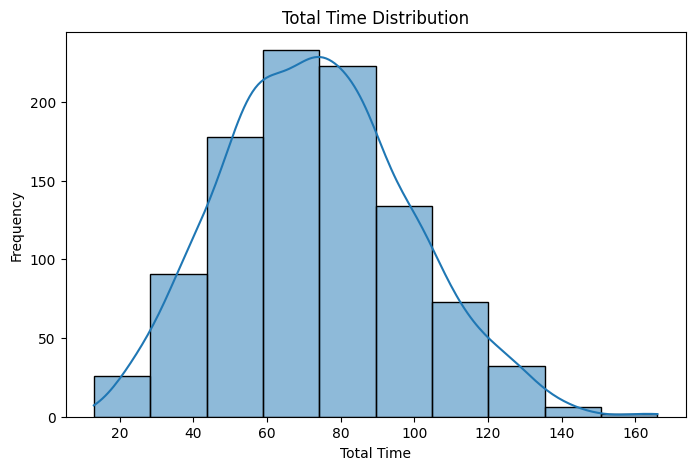

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Time'], bins=10, kde=True)
plt.title('Total Time Distribution')
plt.xlabel('Total Time')
plt.ylabel('Frequency')
plt.show()

**Insight:**
Most delivery orders were concentrated between approximately 50 and 90 minutes, while extremely long delivery times appeared less frequently and may represent operational outliers.


### Customer Satisfaction Distribution

This pie chart illustrates the proportion of customer satisfaction categories based on total delivery time, providing an overview of overall delivery performance quality.


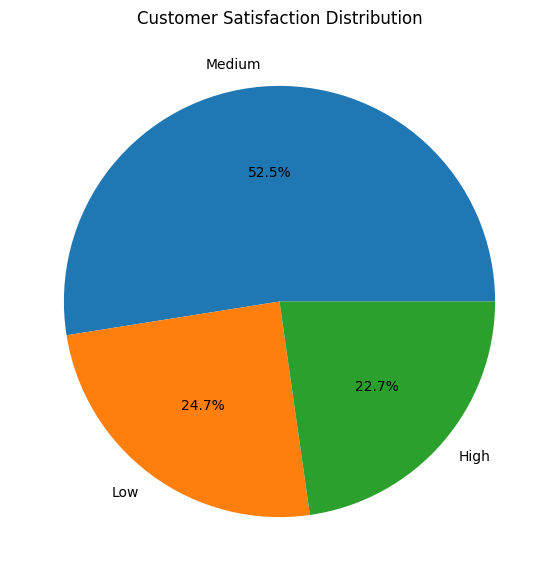

In [32]:
df['Customer_Satisfaction'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(7,7))
plt.title('Customer Satisfaction Distribution')
plt.ylabel('')
plt.show()

**Insight:**
Most orders were classified under the medium satisfaction category, while high satisfaction represented a smaller proportion of deliveries. This suggests that delivery performance was generally moderate, with opportunities to improve delivery efficiency and increase customer satisfaction levels.


### Number of Orders by Time of Day and Weather Conditions

This visualization explores how order volume changes across different times of the day under various weather conditions, helping identify operational demand patterns.


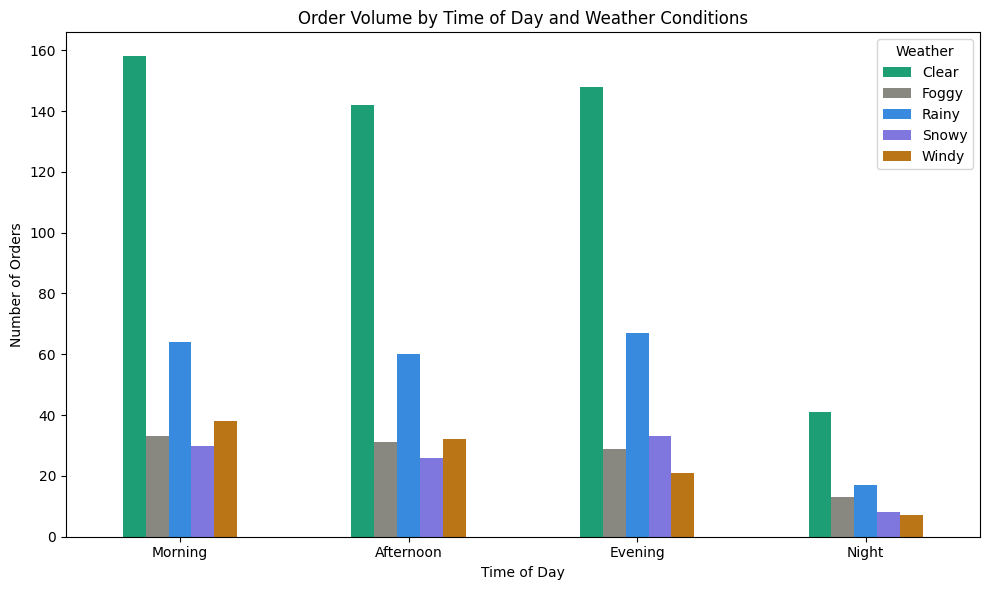

In [33]:
weather_orders = df.groupby(['Time_of_Day', 'Weather']).size().unstack()
order = ['Morning', 'Afternoon', 'Evening', 'Night']
weather_orders = weather_orders.reindex(order)
weather_colors = {
    'Clear': '#1D9E75',
    'Rainy': '#378ADD',
    'Foggy': '#888780',
    'Windy': '#BA7517',
    'Snowy': '#7F77DD'}
plt.figure(figsize=(10, 6))
weather_orders.plot(
    kind='bar',
    color=[weather_colors[col] for col in weather_orders.columns],
    ax=plt.gca())
plt.title('Order Volume by Time of Day and Weather Conditions')
plt.xlabel('Time of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.legend(title='Weather')
plt.tight_layout()
plt.show()

**Insight:**
Clear weather conditions consistently showed the highest order volume across all periods of the day, especially during morning and evening hours. Order activity decreased significantly during night periods and under harsher weather conditions such as snowy and windy environments.


<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

# SQL Analysis & Business Insights

SQL queries were used to analyze operational performance, customer satisfaction trends, delivery efficiency, and the impact of weather and traffic conditions on food delivery operations. The analysis focuses on extracting meaningful business insights from the cleaned dataset using filtering, aggregation, grouping, and statistical calculations.


In [35]:
df.to_csv('Food_Delivery_Cleaned.csv', index=False)

In [36]:
conn = sqlite3.connect('Food_Delivery.db')

In [37]:
df.to_sql('Food_Delivery', conn, if_exists='replace', index=False)

998

In [38]:
%load_ext sql

In [39]:
%sql sqlite:///food_delivery.db

In [40]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

The following steps initialize the SQL environment inside Jupyter Notebook, connect the SQLite database, and enable direct SQL querying for business analysis.


<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

### 1. What is the average total delivery time for each traffic level?

The query calculates the average total delivery time for each traffic condition to evaluate how traffic congestion affects delivery efficiency.


In [41]:
%%sql
SELECT Traffic_Level, 
ROUND(AVG(Total_Time)) As Avg_Total_Time
FROM food_delivery
GROUP BY Traffic_Level
ORDER BY Avg_Total_Time DESC;

 * sqlite:///food_delivery.db
Done.


Traffic_Level,Avg_Total_Time
High,82.0
Medium,73.0
Low,70.0


**Insight:**
High traffic conditions recorded the longest average delivery time at approximately 82 minutes, while low traffic conditions showed the shortest average delivery time at around 70 minutes. This indicates a strong relationship between traffic congestion and delivery delays.


### 2. Which weather condition results in the longest average delivery time?

This query analyzes the average total delivery time under different weather conditions to evaluate how environmental factors influence delivery performance.

In [42]:
%%sql
SELECT Weather,
ROUND(AVG(Total_Time),2) As Avg_Total_Time
FROM food_delivery
GROUP BY Weather
ORDER BY Avg_Total_Time DESC;

 * sqlite:///food_delivery.db
Done.


Weather,Avg_Total_Time
Snowy,84.52
Rainy,77.28
Foggy,76.05
Windy,71.36
Clear,69.76


**Insight:**
Snowy weather conditions recorded the highest average delivery time at approximately 84.5 minutes, followed by rainy and foggy conditions. In contrast, clear weather achieved the lowest average delivery time at around 69.8 minutes. This indicates that severe weather conditions significantly reduce delivery efficiency and increase operational delays.

### 3. Which time of day has the highest number of delivery orders?

This query examines delivery demand across different periods of the day by calculating the total number of orders for each time category.

In [43]:
%%sql
SELECT Time_of_Day,
COUNT(*) As Total_Orders
FROM food_delivery
GROUP BY Time_of_Day
ORDER BY Total_Orders DESC;

 * sqlite:///food_delivery.db
Done.


Time_of_Day,Total_Orders
Morning,323
Evening,298
Afternoon,291
Night,86


**Insight:**
Morning periods recorded the highest number of delivery orders with 323 orders, followed closely by evening and afternoon periods. Night periods showed significantly lower order activity with only 86 orders, indicating reduced operational demand during late hours.

### 4. Which vehicle type has the fastest average delivery time?

This query compares the average total delivery time across different vehicle types to evaluate delivery efficiency and transportation performance.

In [44]:
%%sql
SELECT Vehicle_Type,
ROUND(AVG(Total_Time)) As Avg_Total_Time
FROM food_delivery
GROUP BY Vehicle_Type
ORDER BY Avg_Total_Time ASC;

 * sqlite:///food_delivery.db
Done.


Vehicle_Type,Avg_Total_Time
Bike,73.0
Scooter,73.0
Car,75.0


**Insight:**
Bike and scooter deliveries recorded the fastest average delivery times at approximately 73 minutes, while car deliveries showed a slightly higher average delivery time of around 75 minutes. This suggests that smaller vehicles may navigate traffic conditions more efficiently during food delivery operations.


### 5. Which vehicle type performs best for long-distance deliveries above 15 km?

This query evaluates vehicle performance for long-distance deliveries by analyzing orders with delivery distances greater than 15 kilometers.

In [45]:
%%sql
SELECT Vehicle_Type,
ROUND(AVG(Total_Time)) As Avg_Total_Time
FROM food_delivery  WHERE Distance_km > 15
GROUP BY Vehicle_Type
ORDER BY Avg_Total_Time ASC;

 * sqlite:///food_delivery.db
Done.


Vehicle_Type,Avg_Total_Time
Car,96.0
Bike,97.0
Scooter,97.0


**Insight:**
Cars achieved the lowest average delivery time for long-distance deliveries at approximately 96 minutes, slightly outperforming bikes and scooters. This indicates that cars may provide better efficiency and stability for extended delivery routes.


### 6. Which weather and traffic combination creates the worst delivery performance?

This query analyzes the combined impact of weather conditions and traffic levels on average delivery performance to identify the most challenging operational situations.



In [46]:
%%sql
SELECT Weather, 
Traffic_Level,
ROUND(AVG(Total_Time)) As Avg_Total_Time
FROM food_delivery
GROUP BY Weather, Traffic_Level
ORDER BY Avg_Total_Time DESC;

 * sqlite:///food_delivery.db
Done.


Weather,Traffic_Level,Avg_Total_Time
Rainy,High,96.0
Snowy,High,90.0
Snowy,Medium,88.0
Foggy,High,83.0
Foggy,Medium,81.0
Snowy,Low,80.0
Windy,High,79.0
Clear,High,73.0
Rainy,Low,73.0
Clear,Medium,71.0


**Insight:**
The combination of snowy weather and high traffic recorded the highest average delivery time at approximately 90 minutes, followed by snowy weather with medium traffic and foggy weather with high traffic. This demonstrates that severe weather conditions combined with traffic congestion create the greatest delivery delays and operational challenges.


### 7. How does customer satisfaction change across different weather conditions?

This query examines how customer satisfaction levels vary under different weather conditions by comparing the number of orders within each satisfaction category.



In [47]:
%%sql
SELECT Weather,
Customer_Satisfaction,
COUNT(*) AS Total_Orders
FROM food_delivery
GROUP BY Weather, Customer_Satisfaction
ORDER BY Weather, Total_Orders DESC;

 * sqlite:///food_delivery.db
Done.


Weather,Customer_Satisfaction,Total_Orders
Clear,Medium,255
Clear,High,132
Clear,Low,102
Foggy,Medium,59
Foggy,Low,27
Foggy,High,20
Rainy,Medium,107
Rainy,Low,62
Rainy,High,39
Snowy,Medium,53


**Insight:**
Clear weather conditions recorded the highest number of high and medium satisfaction orders, while more difficult weather conditions showed lower customer satisfaction levels overall. This suggests that favorable weather conditions contribute to faster deliveries and a better customer experience.


### 8. How does customer satisfaction vary across different traffic levels?

This query analyzes customer satisfaction levels under different traffic conditions to evaluate the impact of traffic congestion on customer experience.



In [48]:
%%sql
SELECT Traffic_Level,
Customer_Satisfaction,
COUNT(*) As Total_Orders
FROM food_delivery
GROUP BY Traffic_Level, Customer_Satisfaction
ORDER BY Traffic_Level, Total_Orders DESC;

 * sqlite:///food_delivery.db
Done.


Traffic_Level,Customer_Satisfaction,Total_Orders
High,Medium,107
High,Low,68
High,High,28
Low,Medium,204
Low,High,107
Low,Low,80
Medium,Medium,213
Medium,Low,99
Medium,High,92


**Insight:**
High traffic conditions recorded the lowest number of high satisfaction orders and a relatively high number of low satisfaction orders. In contrast, low and medium traffic conditions showed better customer satisfaction overall. This indicates that traffic congestion negatively affects delivery performance and customer experience.


### 9. Which delivery orders had the longest total delivery times?

This query identifies the delivery orders with the highest total delivery times to detect operational outliers and unusually delayed deliveries.



In [49]:
%%sql
SELECT * 
FROM food_delivery 
ORDER BY Total_Time DESC
LIMIT 15;

 * sqlite:///food_delivery.db
Done.


Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Total_Time,Customer_Satisfaction
446,18.97,Clear,Low,Evening,Car,25,4.0,141,166,Low
394,15.64,Rainy,Low,Morning,Bike,20,4.0,141,161,Low
385,14.83,Rainy,Low,Morning,Car,19,4.0,126,145,Low
428,17.81,Windy,High,Evening,Bike,21,4.0,122,143,Low
367,19.24,Snowy,Low,Morning,Bike,26,1.0,114,140,Low
179,18.77,Snowy,Medium,Evening,Bike,24,0.0,115,139,Low
500,19.73,Foggy,Medium,Evening,Bike,27,4.0,111,138,Low
155,19.72,Rainy,Low,Afternoon,Bike,27,6.0,109,136,Low
105,18.2,Windy,Medium,Morning,Bike,27,1.0,108,135,Low
45,5.55,Foggy,High,Evening,Bike,18,1.0,116,134,Low


**Insight:**
The longest delivery orders exceeded 140 minutes and were commonly associated with long delivery distances, difficult weather conditions, and low customer satisfaction levels. These results highlight operational situations that may require performance optimization and delivery route improvements.


### 10. Which time of day records the highest average total delivery time?

This query calculates the average total delivery time across different periods of the day to identify when delivery operations experience the greatest delays.



In [50]:
%%sql
SELECT Time_of_Day,
ROUND(AVG(Total_Time),2) As Avg_Total_Time
FROM food_delivery
GROUP BY Time_of_Day
ORDER BY Avg_Total_Time DESC;

 * sqlite:///food_delivery.db
Done.


Time_of_Day,Avg_Total_Time
Evening,74.97
Morning,73.1
Afternoon,73.01
Night,72.56


**Insight:**
Evening periods recorded the highest average total delivery time at approximately 75 minutes, slightly higher than morning, afternoon, and night periods. This suggests that increased demand and traffic congestion during evening hours may reduce delivery efficiency.


### 11. Which vehicle type achieves the highest customer satisfaction?

This query identifies the vehicle type associated with the highest number of highly satisfied customers to evaluate transportation performance and service quality.




In [51]:
%%sql
SELECT Vehicle_Type,
COUNT(*) As High_Satisfaction_Orders
FROM food_delivery
WHERE Customer_Satisfaction = 'High'
GROUP BY Vehicle_Type
ORDER BY High_Satisfaction_Orders DESC;

 * sqlite:///food_delivery.db
Done.


Vehicle_Type,High_Satisfaction_Orders
Bike,120
Scooter,69
Car,38


**Insight:**
Bike deliveries achieved the highest number of high satisfaction orders with 120 deliveries, significantly outperforming scooters and cars. This suggests that bikes may provide faster and more flexible delivery performance, leading to improved customer satisfaction.

### 12. What percentage of deliveries fall into each customer satisfaction category?

This query calculates the distribution and percentage of deliveries across different customer satisfaction categories to evaluate overall service quality.



In [52]:
%%sql
SELECT Customer_Satisfaction,
COUNT(*) As Total_Orders,
ROUND(COUNT(*)*100.0 / (SELECT COUNT(*) FROM food_delivery),2) || '%' AS Percentage_of_Deliveries
FROM food_delivery
GROUP BY Customer_Satisfaction
ORDER BY Total_Orders desc;

 * sqlite:///food_delivery.db
Done.


Customer_Satisfaction,Total_Orders,Percentage_of_Deliveries
Medium,524,52.51%
Low,247,24.75%
High,227,22.75%


**Insight:**
Most deliveries fell within the medium satisfaction category, representing approximately 52.5% of total deliveries. Low satisfaction accounted for around 24.8% of deliveries, while the remaining deliveries belonged to the high satisfaction category. These results indicate that overall delivery performance was generally moderate, with opportunities to improve customer experience and increase satisfaction levels.


### 13. Which operational factors are most associated with low customer satisfaction?

This query analyzes combinations of weather conditions, traffic levels, and vehicle types associated with low customer satisfaction orders to identify operational challenges affecting delivery quality.



In [53]:
%%sql
SELECT Weather,
Traffic_Level,
Vehicle_Type,
COUNT(*) As Low_Satisfaction_Orders
FROM food_delivery
WHERE Customer_Satisfaction='Low'
GROUP BY Weather, Traffic_Level, Vehicle_Type
ORDER BY Low_Satisfaction_Orders DESC;

 * sqlite:///food_delivery.db
Done.


Weather,Traffic_Level,Vehicle_Type,Low_Satisfaction_Orders
Clear,Medium,Bike,25
Clear,Low,Bike,21
Clear,Medium,Scooter,16
Rainy,High,Scooter,11
Rainy,High,Bike,10
Rainy,Low,Bike,10
Clear,High,Bike,9
Clear,Low,Scooter,9
Rainy,Medium,Scooter,9
Rainy,Medium,Bike,8


**Insight:**
Low customer satisfaction orders were most commonly associated with bike deliveries under medium traffic and clear weather conditions. In addition, rainy weather combined with high traffic conditions also contributed to increased low satisfaction orders. These findings suggest that traffic congestion, weather conditions, and delivery workload collectively influence customer experience and operational performance.


<hr style="height:15px;border:none;background:linear-gradient(to right, #00c9a7, #00bfff);">

# Conclusion

This project analyzed food delivery operations to identify the key factors affecting delivery time and customer satisfaction. The analysis was conducted across three stages: Python for data preparation and exploratory analysis, SQL for business intelligence, and Power BI for interactive reporting.

---

## Key Findings

### Weather impact
Snowy conditions produced the longest average delivery time at approximately 84.5 minutes, compared to approximately 69.8 minutes in clear weather.

### Traffic impact
High traffic levels extended average delivery time to approximately 82 minutes, while low traffic averaged approximately 70 minutes.

### Vehicle performance
Bikes led in customer satisfaction and short-distance speed, while cars performed best for distances above 15 km.

---

## Critical Operational Insight

The worst operational scenario identified was the combination of snowy weather and high traffic, which produced an average total delivery time of approximately 90 minutes and was strongly associated with low customer satisfaction. Addressing this scenario through smarter vehicle dispatch and route planning represents the highest-impact operational opportunity.

---

## Summary

Overall, the project demonstrated that delivery performance is shaped by a combination of environmental, operational, and logistical factors. The findings provide a foundation for data-driven decisions around vehicle allocation, scheduling, and customer experience improvement.

Data cleaning, feature engineering, statistical analysis, SQL-based business intelligence, and operational storytelling were applied throughout — skills that translate directly to real-world analytics roles.